In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1")

In [2]:
from keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow import keras
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, accuracy_score
from keras import regularizers

In [ ]:
dataFolder = '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/chest_xray'
#dataFolder = '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/dummy'

dataDict = {}
folder = 'test'
insideFolder = dataFolder + '/' + folder
dataDict[f'{folder}_y'] = []
dataDict[f'{folder}_im'] = []
print("start going through folder: " + folder)
for subfolder in os.listdir(insideFolder):
  subfolder = insideFolder + '/' + subfolder + '/'

  #y = []
  images = []
  dir = subfolder
  ext = ['jpeg']

  path=os.path.dirname(dir)
  if os.path.basename(path) == 'NORMAL':
    y = [0 for i in range(0,len(os.listdir(dir)))]
  else:
    y = [1 for i in range(0,len(os.listdir(dir)))]

  files = []
  [files.extend(glob.glob(dir + '*.' + e)) for e in ext]
  for file in files:
    im = cv2.imread(file)
    recized_im = cv2.resize(im,(224, 224)) 
    images.append(recized_im)
  dataDict[f'{folder}_y'] += y
  dataDict[f'{folder}_im'] += images
  
  print("done with subfolder: " + os.path.basename(path))
print("done with folder: " + folder)  

start going through folder: test
done with subfolder: NORMAL
done with subfolder: PNEUMONIA
done with folder: test


In [ ]:
X_test_CNN = tf.convert_to_tensor(dataDict['test_im'], dtype='float32')
X_test_CNN /= 255.0

In [9]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = test_datagen.flow_from_directory(
        '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/chest_xray/train',
        target_size=(224, 224),
        batch_size=64,
        class_mode='binary')
train_generator_aug = train_datagen.flow_from_directory(
        '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/chest_xray/train',
        target_size=(224, 224),
        batch_size=64,
        class_mode='binary')
validation_generator = test_datagen.flow_from_directory(
        '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/chest_xray/val',
        target_size=(224, 224),
        batch_size=64,
        class_mode='binary')


Found 5216 images belonging to 2 classes.
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [13]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False)

for layer in base_model.layers[:-5]:
    layer.trainable = False

for layer in base_model.layers[-5:]:
    layer.trainable = True

#for layer in base_model.layers[10:]:
#    layer.trainable = False
#

inputs = keras.Input(shape=(224, 224, 3))
x = inputs
x = keras.layers.BatchNormalization(axis=1)(x)
x = base_model(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(units = 512, activation = 'relu', kernel_regularizer=regularizers.l2(l=0.03))(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(units = 2, activation = 'softmax')(x)

myVGG = keras.Model(inputs, outputs)

myVGG.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

print(len(myVGG.trainable_variables))

12


In [6]:
myVGG.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 batch_normalization_2 (Batc  (None, 224, 224, 3)      896       
 hNormalization)                                                 
                                                                 
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 flatten_2 (Flatten)         (None, 25088)             0         
                                                                 
 dense_4 (Dense)             (None, 512)               12845568  
                                                                 
 dropout_2 (Dropout)         (None, 512)               0         
                                                           

In [ ]:
history = myVGG.fit(
        train_generator_aug,
        steps_per_epoch=64,
        epochs=20,
        validation_data=validation_generator,
        validation_steps=1)

# summarize history for accuracy
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Epoch 1/20
64/64 [==============================] - 451s 7s/step - loss: 19.0412 - sparse_categorical_accuracy: 0.8688 - val_loss: 12.4417 - val_sparse_categorical_accuracy: 0.5000
Epoch 2/20
64/64 [==============================] - 174s 3s/step - loss: 6.1849 - sparse_categorical_accuracy: 0.9619 - val_loss: 5.3342 - val_sparse_categorical_accuracy: 0.5000
Epoch 3/20
64/64 [==============================] - 115s 2s/step - loss: 2.2983 - sparse_categorical_accuracy: 0.9731 - val_loss: 1.7393 - val_sparse_categorical_accuracy: 0.8125
Epoch 4/20
64/64 [==============================] - 97s 2s/step - loss: 1.1430 - sparse_categorical_accuracy: 0.9783 - val_loss: 1.1032 - val_sparse_categorical_accuracy: 0.8125
Epoch 5/20
64/64 [==============================] - 90s 1s/step - loss: 0.7226 - sparse_categorical_accuracy: 0.9791 - val_loss: 0.9917 - val_sparse_categorical_accuracy: 0.7500
Epoch 6/20
64/64 [==============================] - 91s 1s/step - loss: 0.5075 - sparse_categorical_accur

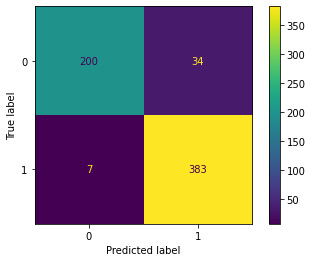

accuracy is : 0.9342948717948718
recall is : 0.982051282051282
precision is: 0.9184652278177458


In [ ]:
y_test_CNN = dataDict['test_y']
y_test_hat_hold = myResnet.predict(X_test_CNN)
y_test_hat = np.argmax(y_test_hat_hold, axis=1)
c_mtx = confusion_matrix(y_test_CNN,y_test_hat)

disp = ConfusionMatrixDisplay(confusion_matrix=c_mtx)
disp.plot()
plt.show()


print('accuracy is : ' + str(accuracy_score(y_test_CNN,y_test_hat)))
print('recall is : ' + str(recall_score(y_test_CNN,y_test_hat)))
print('precision is: ' + str(precision_score(y_test_CNN,y_test_hat)))

Old data upload

In [ ]:
## get data with augmantation
#
#data_augmentation = tf.keras.Sequential([
#  keras.layers.RandomFlip("horizontal_and_vertical"),
#  keras.layers.RandomRotation(0.2),
#])
#
#dataFolder = '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/chest_xray'
##dataFolder = '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/dummy'
#
#dataDict = {}
#for folder in os.listdir(dataFolder):
#  insideFolder = dataFolder + '/' + folder
#  dataDict[f'{folder}_y'] = []
#  dataDict[f'{folder}_im'] = []
#  print("start going through folder: " + folder)
#  for subfolder in os.listdir(insideFolder):
#    subfolder = insideFolder + '/' + subfolder + '/'
#
#    #y = []
#    images = []
#    dir = subfolder
#    ext = ['jpeg']
#
#    path=os.path.dirname(dir)
#    if os.path.basename(path) == 'NORMAL':
#      y = [0 for i in range(0,len(os.listdir(dir)))]
#    else:
#      y = [1 for i in range(0,len(os.listdir(dir)))]
#
#    files = []
#    [files.extend(glob.glob(dir + '*.' + e)) for e in ext]
#    for file in files:
#      im = cv2.imread(file)
#      recized_im = cv2.resize(im,(224, 224)) 
#      images.append(recized_im)
#    dataDict[f'{folder}_y'] += y
#    dataDict[f'{folder}_im'] += images
#
#    if folder == 'train':
#      if os.path.basename(path) == 'NORMAL':
#        aug_im_h = data_augmentation(np.array(images))
#        aug_im_h2 = np.array(aug_im_h)
#        aug_im = aug_im_h2.tolist()
#
#        dataDict[f'{folder}_im'] += aug_im
#        dataDict[f'{folder}_y'] += y
#
#    print("done with subfolder: " + os.path.basename(path))
#  print("done with folder: " + folder)

start going through folder: test
done with subfolder: NORMAL
done with subfolder: PNEUMONIA
done with folder: test
start going through folder: train
done with subfolder: NORMAL
done with subfolder: PNEUMONIA
done with folder: train
start going through folder: val
done with subfolder: PNEUMONIA
done with subfolder: NORMAL
done with folder: val


In [ ]:
#dataFolder = '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/chest_xray'
##dataFolder = '/content/drive/MyDrive/Colab Notebooks/CNN_HW/HW1/dummy'
#
#dataDict = {}
#for folder in os.listdir(dataFolder):
#  insideFolder = dataFolder + '/' + folder
#  dataDict[f'{folder}_y'] = []
#  dataDict[f'{folder}_im'] = []
#  print("start going through folder: " + folder)
#  for subfolder in os.listdir(insideFolder):
#    subfolder = insideFolder + '/' + subfolder + '/'
#
#    #y = []
#    images = []
#    dir = subfolder
#    ext = ['jpeg']
#
#    path=os.path.dirname(dir)
#    if os.path.basename(path) == 'NORMAL':
#      y = [0 for i in range(0,len(os.listdir(dir)))]
#    else:
#      y = [1 for i in range(0,len(os.listdir(dir)))]
#
#    files = []
#    [files.extend(glob.glob(dir + '*.' + e)) for e in ext]
#    for file in files:
#      im = cv2.imread(file)
#      recized_im = cv2.resize(im,(224, 224)) 
#      images.append(recized_im)
#    dataDict[f'{folder}_y'] += y #needs to be fixed
#    dataDict[f'{folder}_im'] += images
#    
#    print("done with subfolder: " + os.path.basename(path))
#  print("done with folder: " + folder)  

start going through folder: test


KeyboardInterrupt: ignored

In [ ]:
### convert to tensor for CNN
#
#X_train_CNN = tf.convert_to_tensor(dataDict['train_im'], dtype='float32')
#X_train_CNN /= 255.0
#y_train_CNN = tf.convert_to_tensor(dataDict['train_y'])
#
#X_val_CNN = tf.convert_to_tensor(dataDict['val_im'], dtype='float32')
#X_val_CNN /= 255.0
#y_val_CNN = tf.convert_to_tensor(dataDict['val_y'])
#
#X_test_CNN = tf.convert_to_tensor(dataDict['test_im'], dtype='float32')
#X_test_CNN /= 255.0